# `Problem statement:`
    The objective of this project is to analyze the Diamonds dataset and build a Machine Learning model to predict diamond prices based on features such as carat, cut, color, clarity, depth, table and dimensions. The project also involves data preprocessing, handling skewness, and comparing different regression models to achieve accurate price prediction


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
data = pd.read_csv('diamonds.csv')
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [5]:
data.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [6]:
data.dtypes

carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

In [7]:
data.shape

(53940, 10)

In [8]:
data.isna().sum()/len(data)

carat      0.0
cut        0.0
color      0.0
clarity    0.0
depth      0.0
table      0.0
price      0.0
x          0.0
y          0.0
z          0.0
dtype: float64

In [9]:
data[data.duplicated(keep=False)]

,carat,cut,color,clarity,depth,table,price,x,y,z
1004,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1005,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1006,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1007,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1008,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
...,...,...,...,...,...,...,...,...,...,...
49557,0.71,Good,F,SI2,64.1,60.0,2130,0.00,0.00,0.00
50078,0.51,Ideal,F,VVS2,61.2,56.0,2203,5.19,5.17,3.17
50079,0.51,Ideal,F,VVS2,61.2,56.0,2203,5.19,5.17,3.17
52860,0.50,Fair,E,VS2,79.0,73.0,2579,5.21,5.18,4.09


In [10]:
(data.duplicated().sum() / len(data)) * 100

np.float64(0.2706711160548758)

In [11]:
## Duplicate rows are very few (0.27%) so they do not affect the analysis significantly ,therefore the data is kept as it is

### Univariate Analysis

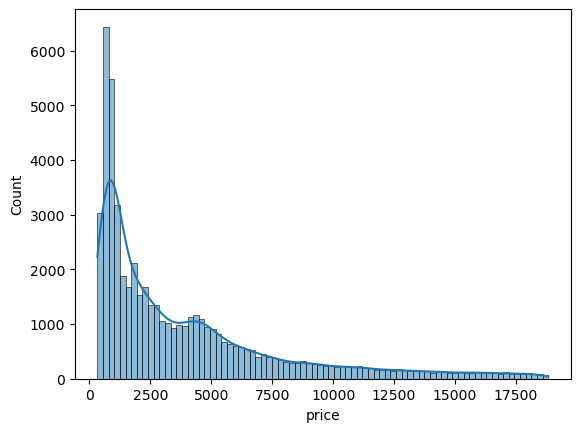

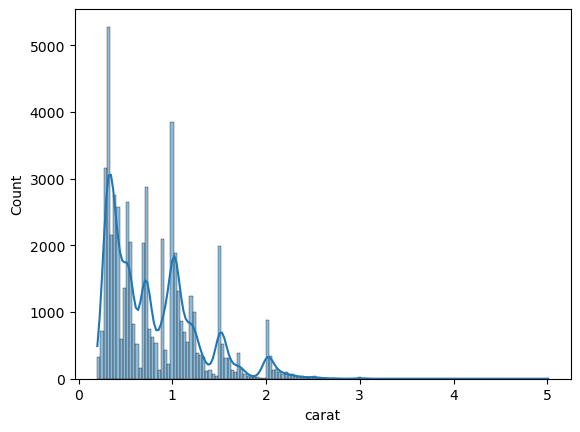

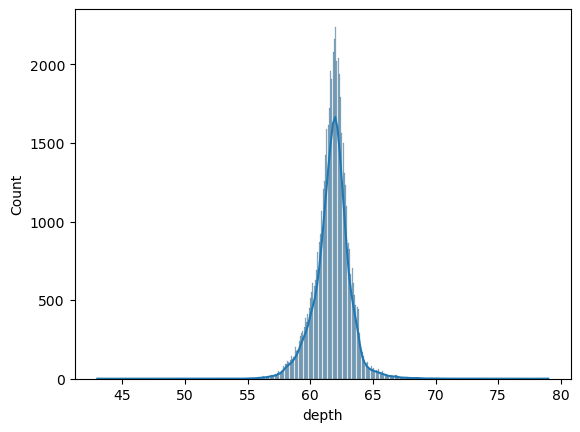

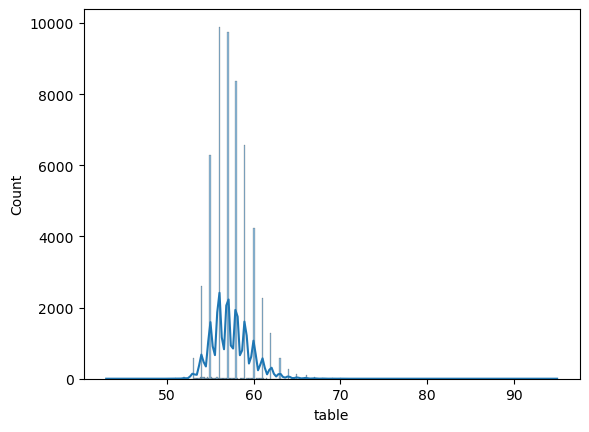

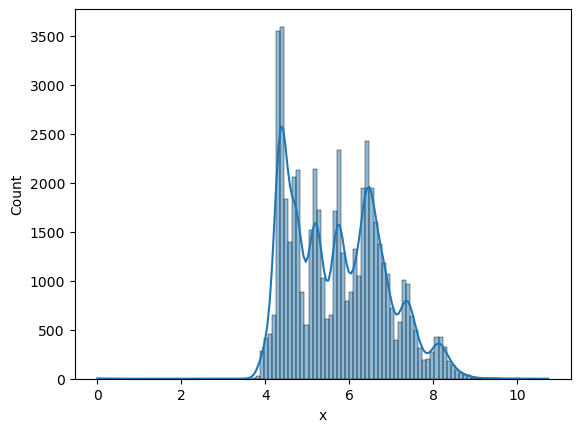

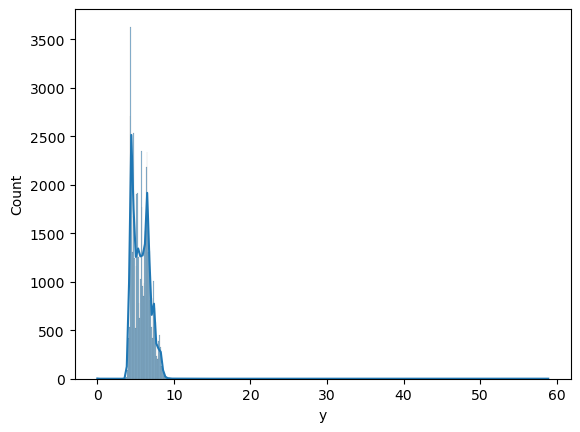

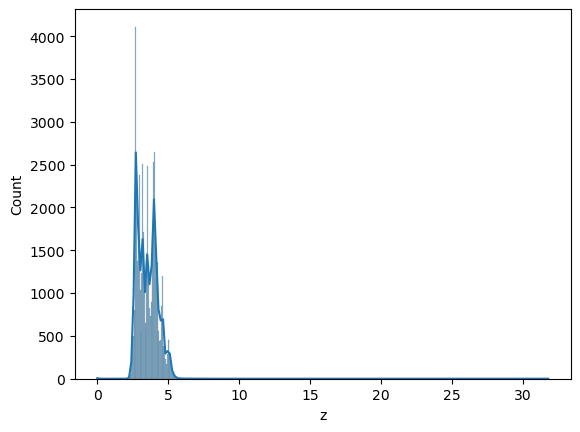

In [12]:
num_col=['price','carat','depth','table','x','y','z']
for col in num_col:
    sns.histplot(data=data,x=col,kde=True)
    plt.show()

In [13]:
data[['price','carat','depth','table','x','y','z']].describe()

,price,carat,depth,table,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,3932.799722,0.797940,61.749405,57.457184,5.731157,5.734526,3.538734
std,3989.439738,0.474011,1.432621,2.234491,1.121761,1.142135,0.705699
min,326.000000,0.200000,43.000000,43.000000,0.000000,0.000000,0.000000
25%,950.000000,0.400000,61.000000,56.000000,4.710000,4.720000,2.910000
50%,2401.000000,0.700000,61.800000,57.000000,5.700000,5.710000,3.530000
75%,5324.250000,1.040000,62.500000,59.000000,6.540000,6.540000,4.040000
max,18823.000000,5.010000,79.000000,95.000000,10.740000,58.900000,31.800000


In [14]:
data = data[(data['x'] > 0) & (data['x'] < 20) &
            (data['y'] > 0) & (data['y'] < 20) &
            (data['z'] > 0) & (data['z'] < 20)]


In [15]:
data['price_log'] = np.log(data['price'])
data[['price','price_log']].head()

,price,price_log
0,326,5.786897
1,326,5.786897
2,327,5.789960
3,334,5.811141
4,335,5.814131


In [16]:
data = data.drop(columns=['price'])

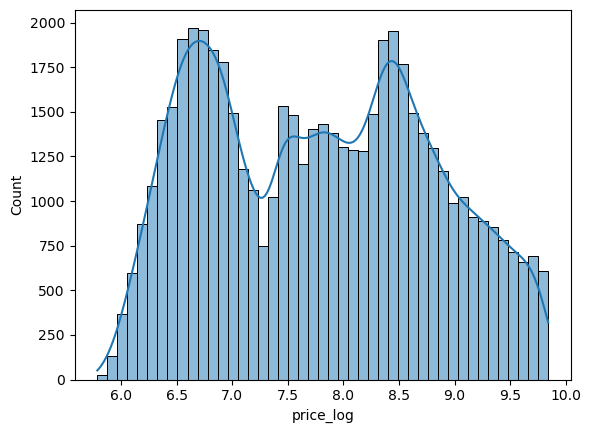

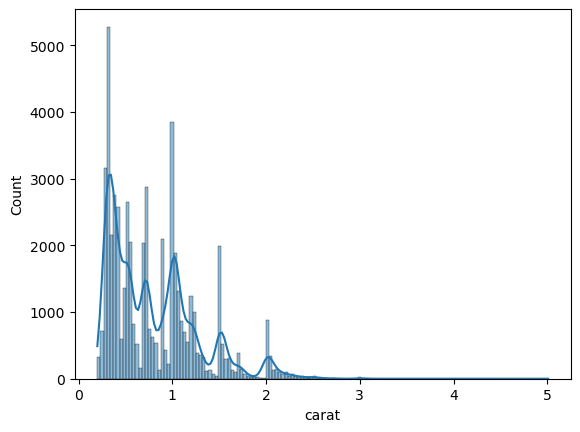

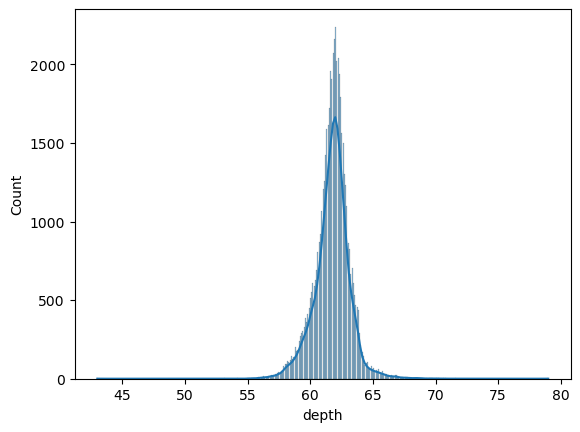

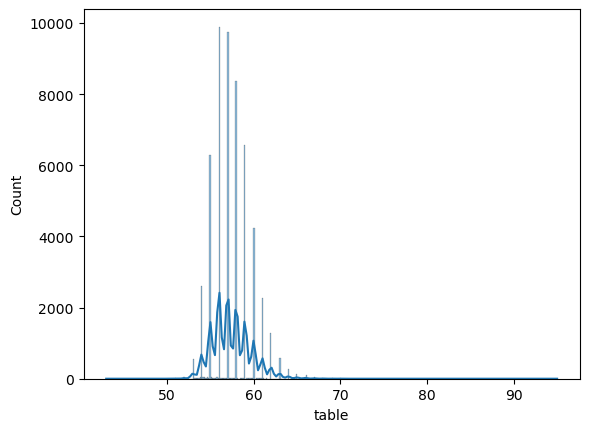

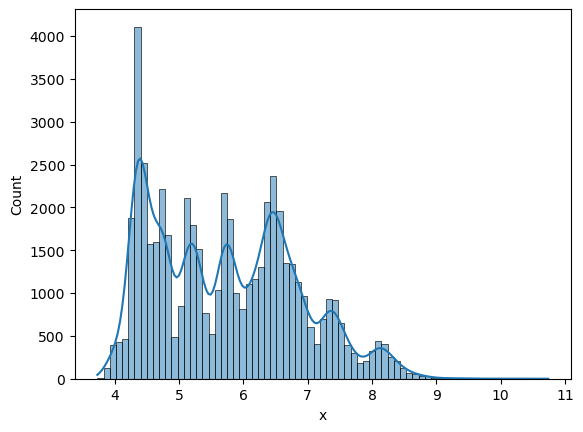

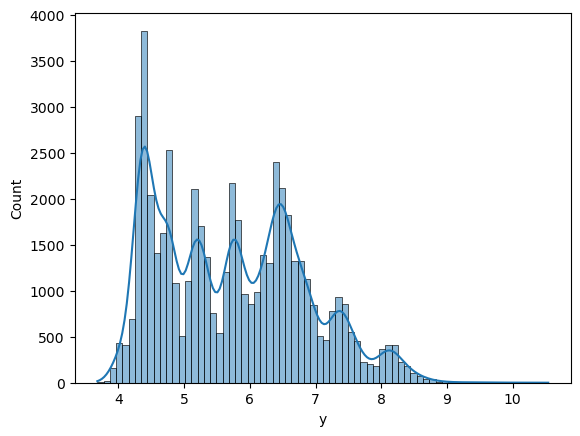

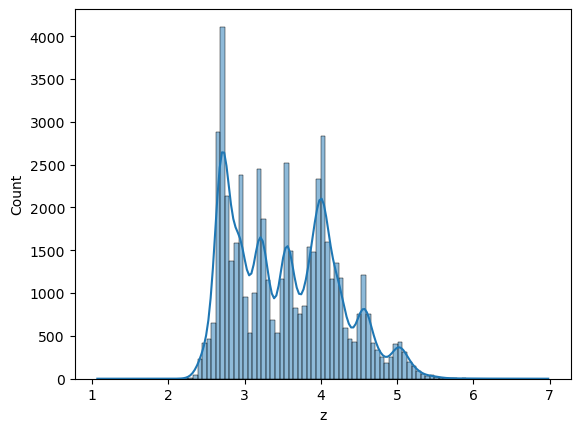

In [17]:
num_col=['price_log','carat','depth','table','x','y','z']
for col in num_col:
    sns.histplot(data=data,x=col,kde=True)
    plt.show()

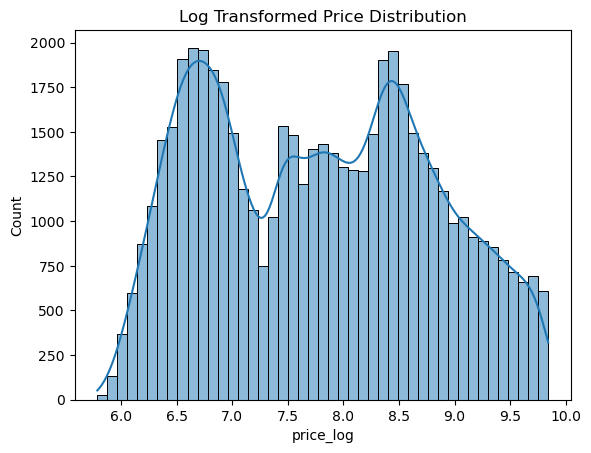

In [18]:
sns.histplot(data['price_log'], kde=True)
plt.title("Log Transformed Price Distribution")
plt.show()

Log transformation reduced the positive skewness in the price feature.

In [19]:
data.head()

,carat,cut,color,clarity,depth,table,x,y,z,price_log
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,5.786897
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,5.786897
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,5.789960
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,5.811141
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,5.814131


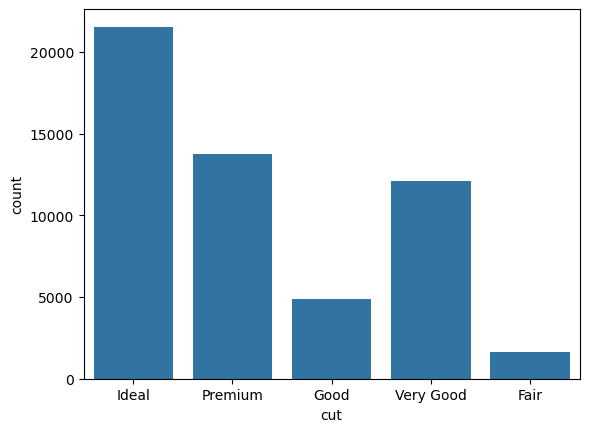

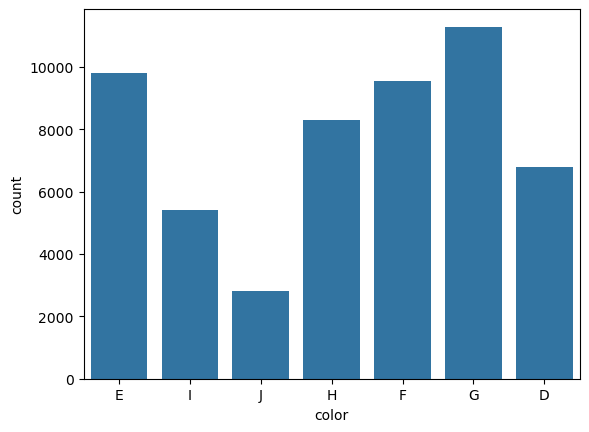

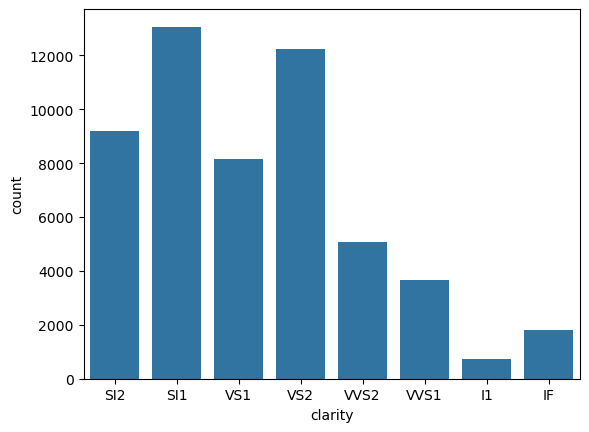

In [20]:
cat_col = ['cut','color','clarity']
for col in cat_col:
    sns.countplot(data=data,x=col)
    plt.show()

### Bivariate Analysis

<function matplotlib.pyplot.show(close=None, block=None)>

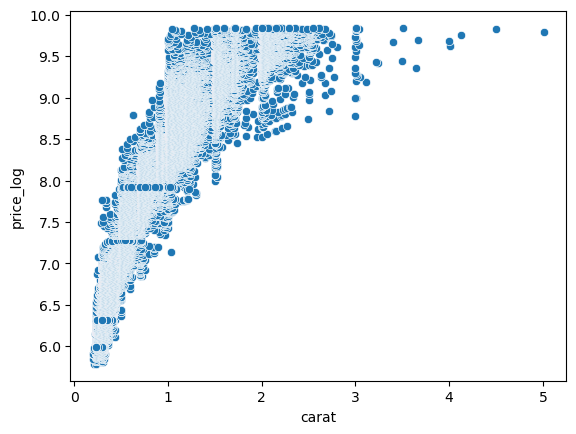

In [21]:
sns.scatterplot(x='carat', y='price_log', data=data)
plt.show

In [22]:
## The scatter plot shows a strong positive correlation between carat and log-transformed price. Larger diamonds generally have higher prices.

<function matplotlib.pyplot.show(close=None, block=None)>

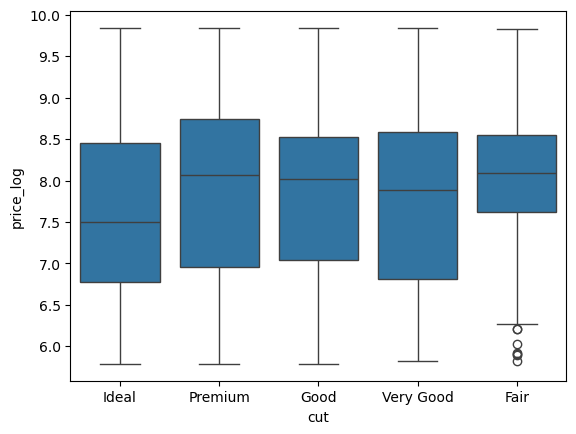

In [23]:
sns.boxplot(x='cut', y='price_log', data=data)
plt.show

In [24]:
## The boxplot shows that diamond prices vary across different cut categories. Premium and Fair cuts tend to have slightly higher median prices, while Ideal cuts show a wider spread of prices

### Multivariate Analysis

<Axes: >

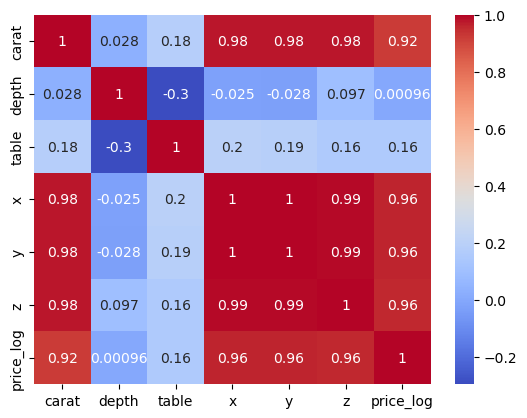

In [25]:
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')

<Axes: >

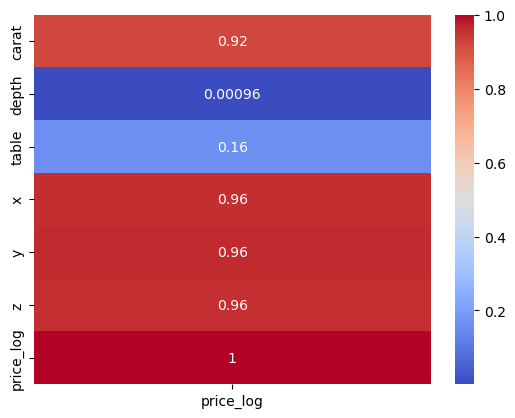

In [26]:
sns.heatmap(data.corr(numeric_only=True)[['price_log']], annot=True, cmap='coolwarm')

In [27]:
from sklearn.preprocessing import LabelEncoder

le_cut = LabelEncoder()
data['cut'] = le_cut.fit_transform(data['cut'])

le_color = LabelEncoder()
data['color'] = le_color.fit_transform(data['color'])

le_clarity = LabelEncoder()
data['clarity'] = le_clarity.fit_transform(data['clarity'])

In [28]:
data

,carat,cut,color,clarity,depth,table,x,y,z,price_log
0,0.23,2,1,3,61.5,55.0,3.95,3.98,2.43,5.786897
1,0.21,3,1,2,59.8,61.0,3.89,3.84,2.31,5.786897
2,0.23,1,1,4,56.9,65.0,4.05,4.07,2.31,5.789960
3,0.29,3,5,5,62.4,58.0,4.20,4.23,2.63,5.811141
4,0.31,1,6,3,63.3,58.0,4.34,4.35,2.75,5.814131
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,2,0,2,60.8,57.0,5.75,5.76,3.50,7.921898
53936,0.72,1,0,2,63.1,55.0,5.69,5.75,3.61,7.921898
53937,0.70,4,0,2,62.8,60.0,5.66,5.68,3.56,7.921898
53938,0.86,3,4,3,61.0,58.0,6.15,6.12,3.74,7.921898


In [29]:
data.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z',
       'price_log'],
      dtype='object')

## Separating Target and Feature Columns

In [30]:
x = data[['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']]
y = data['price_log']
       

### Train & Test split 

In [31]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train

,carat,cut,color,clarity,depth,table,x,y,z
45779,0.51,2,3,4,60.9,56.0,5.16,5.19,3.15
4653,1.12,3,5,3,61.2,58.0,6.72,6.68,4.10
3912,0.78,3,1,5,62.8,60.0,5.86,5.79,3.66
47491,0.49,4,3,1,59.7,56.0,5.16,5.19,3.09
43762,0.53,2,3,2,61.0,55.0,5.23,5.26,3.20
...,...,...,...,...,...,...,...,...,...
11290,1.29,4,2,3,63.4,57.0,6.92,6.77,4.35
44750,0.51,2,2,5,59.2,56.0,5.23,5.18,3.08
38176,0.53,3,4,3,62.5,60.0,5.16,5.18,3.23
860,0.90,3,6,2,62.8,59.0,6.13,6.03,3.82


In [32]:
print(x_train.shape,x_test.shape)

(43133, 9) (10784, 9)


In [33]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)


In [34]:
x_train_sc

array([[-0.60804509, -0.54151326,  0.23601181, ..., -0.51175623,
        -0.49031175, -0.56384603],
       [ 0.67766029,  0.43246995,  1.40908133, ...,  0.88024457,
         0.8490799 ,  0.80857099],
       [-0.03896238,  0.43246995, -0.93705772, ...,  0.11285952,
         0.04904059,  0.17292521],
       ...,
       [-0.56589082,  0.43246995,  0.82254657, ..., -0.51175623,
        -0.49930095, -0.44827407],
       [ 0.21396327,  0.43246995,  1.9956161 , ...,  0.35378273,
         0.26478153,  0.40406913],
       [ 0.86735453,  1.40645317, -0.93705772, ...,  0.93378307,
         0.94796116,  1.05416141]])

## Model Training

In [35]:
lr = LinearRegression()

lr.fit(x_train_sc, y_train)


LinearRegression()

In [36]:
lr_pred = lr.predict(x_test_sc)

In [37]:
print("Training Score:", lr.score(x_train_sc, y_train))
print("Testing Score:", lr.score(x_test_sc, y_test))
print()
print("MSE:", mean_squared_error(y_test, lr_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test, lr_pred)))
print("MAE:", mean_absolute_error(y_test, lr_pred))
print("R2 Score:", r2_score(y_test, lr_pred))

Training Score: 0.9578488269849131
Testing Score: 0.9573938004435949

MSE: 0.04367267697211475
RMSE 0.20898008750145253
MAE: 0.15762647621509854
R2 Score: 0.9573938004435949


In [38]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(x_train, y_train)


DecisionTreeRegressor(random_state=42)

In [39]:
dt_pred = dt.predict(x_test)

In [40]:
print("Training Score:", dt.score(x_train, y_train))
print("Testing Score:", dt.score(x_test, y_test))
print()
print("MSE:", mean_squared_error(y_test, dt_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test, dt_pred)))
print("MAE:", mean_absolute_error(y_test, dt_pred))
print("R2 Score:", r2_score(y_test, dt_pred))

Training Score: 0.9999807322546115
Testing Score: 0.9848112476155398

MSE: 0.015568942628121448
RMSE 0.1247755690354544
MAE: 0.08400479048396371
R2 Score: 0.9848112476155398


In [41]:
rf = RandomForestRegressor(
    max_depth= 15, 
min_samples_leaf= 2, 
min_samples_split= 5,
n_estimators= 100,
random_state=42)
rf.fit(x_train,y_train)

RandomForestRegressor(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                      random_state=42)

In [42]:
rf_pred = rf.predict(x_test)

In [57]:
print("Training Score:", rf.score(x_train, y_train))
print("Testing Score:", rf.score(x_test, y_test))
print()
print("MSE:", mean_squared_error(y_test, rf_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test, rf_pred)))
print("MAE:", mean_absolute_error(y_test, rf_pred)) 
r2 = r2_score(y_test, rf_pred)
print("R2 Score:", r2)

Training Score: 0.99633599491513
Testing Score: 0.992163553794218

MSE: 0.008032600591409075
RMSE 0.08962477666030234
MAE: 0.06398509053642384
R2 Score: 0.992163553794218


In [58]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf,
    x_train,y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:", scores)
print("Average CV Score:", scores.mean())

Cross Validation Scores: [0.99163293 0.99171394 0.99134652 0.99185933 0.99171056]
Average CV Score: 0.9916526569072402


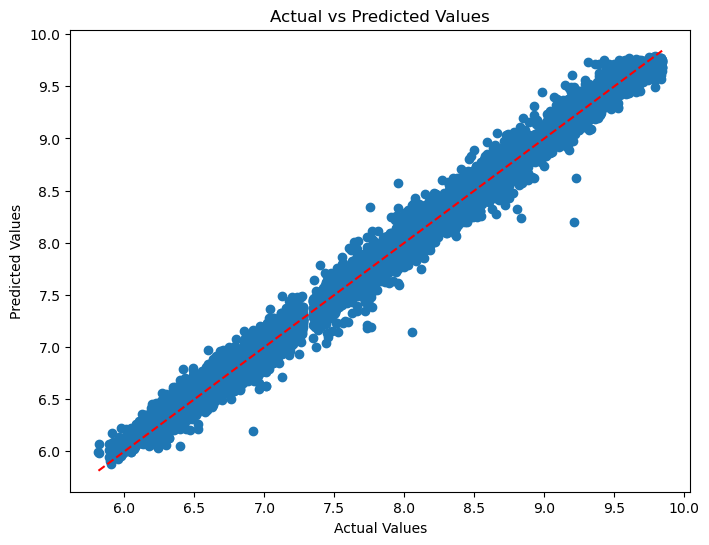

In [45]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Values")

plt.show()

In [46]:
importance = rf.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
7,y,0.828913
0,carat,0.098660
3,clarity,0.030786
6,x,0.022368
2,color,0.015393
8,z,0.001489
4,depth,0.000985
5,table,0.000731
1,cut,0.000675


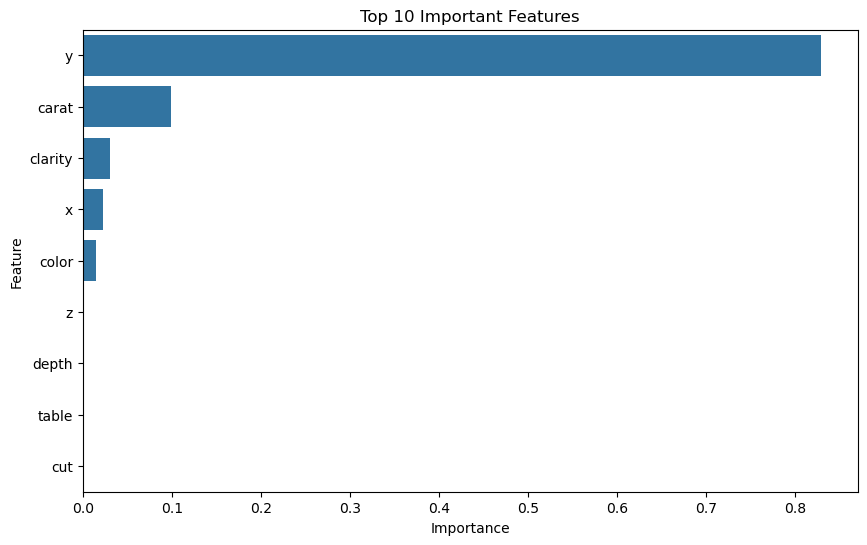

In [47]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title('Top 10 Important Features')
plt.show()

## Model Comparison

In [48]:
models = ['Linear Regression', 'Decision Tree', 'Random Forest']

r2_scores = [
    r2_score(y_test, lr_pred),
    r2_score(y_test, dt_pred),
    r2_score(y_test, rf_pred)
]

comparison = pd.DataFrame({
    'Model': models,
    'R2 Score': r2_scores
})

comparison

,Model,R2 Score
0,Linear Regression,0.957394
1,Decision Tree,0.984811
2,Random Forest,0.992164


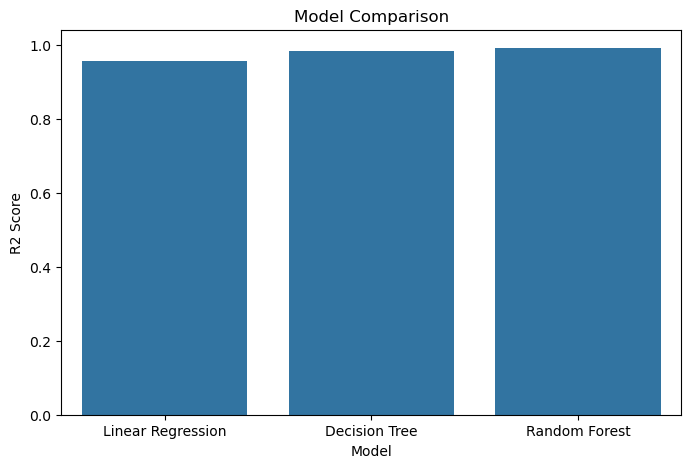

In [49]:
plt.figure(figsize=(8,5))
sns.barplot(data=comparison, x='Model', y='R2 Score')

plt.title('Model Comparison')
plt.show()

## Model Selection

    Based on the R² scores, error metrics, and overall model evaluation results, the Random Forest Regressor achieved the best prediction performance among all the trained models. Linear Regression showed comparatively lower performance, while Decision Tree performed well but was slightly less stable than Random Forest.

    The strong performance of Random Forest is due to its ability to handle complex feature relationships and reduce overfitting by combining multiple decision trees. Therefore, Random Forest Regressor was selected as the final model for this project.

In [62]:
import pickle

data = {
    "Model": rf,
    "le_cut": le_cut,
    "le_color": le_color,
    "le_clarity": le_clarity,
    "r2_score": r2
}

with open("diamond_model.pkl", "wb") as f:
    pickle.dump(data, f)

print("Model Saved Successfully!")

Model Saved Successfully!


## Conclusion
    In this project, diamond price prediction was performed using different regression models including Linear Regression, Decision Tree, and Random Forest Regressor. The dataset was cleaned, analyzed, encoded, and preprocessed before model training. Different visualization techniques were used during EDA to understand feature relationships, outliers, and data distribution.

    After comparing the models using R² score and error metrics, Random Forest Regressor achieved the best performance and provided the most accurate predictions. Features like carat and diamond dimensions showed a strong influence on diamond prices. Therefore, Random Forest Regressor was finalized as the most suitable model for this project.